# 0. Imports and Initial Configs

## 0.1 - Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Torna o pacote `src` importável independente do diretório de execução do kernel
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.models.prophet_model import (
    train_test_split_temporal,
    fit_prophet_model,
    generate_forecast,
)
from src.models.anomaly_detection import flag_anomalies

## 0.2 - Initial Config

In [2]:
# Comando para remover os warnings (o Prophet/cmdstanpy emite avisos verbosos durante o ajuste)
warnings.filterwarnings("ignore")

# Comando para configurar o pandas e remover o limite de exibição
# de linhas e colunas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Adjust Figure size
plt.rcParams['figure.figsize'] = (12, 8)

## 0.3 - Load Data

Série diária de precipitação da RMR (Região Metropolitana do Recife), já corrigida e consolidada na Task 1.6 (`dados/processed/serie_prophet_rmr_2020_2025.csv`), no formato canônico exigido pelo Prophet: colunas `ds` (data) e `y` (precipitação em mm/dia).

In [3]:
df_raw = pd.read_csv(PROJECT_ROOT / "dados" / "processed" / "serie_prophet_rmr_2020_2025.csv")
df_raw['ds'] = pd.to_datetime(df_raw['ds'])

df_raw.head(3)

,ds,y
0,2020-01-01,3.148975
1,2020-01-02,1.878431
2,2020-01-03,1.916259


In [4]:
print(f"Formato: {df_raw.shape}")
print(f"Período: {df_raw['ds'].min().date()} a {df_raw['ds'].max().date()}")

Formato: (2192, 2)
Período: 2020-01-01 a 2025-12-31


# 1. Split Temporal (Treino/Teste)

A validação de modelos de série temporal não pode usar embaralhamento aleatório (`train_test_split` convencional), sob risco de vazamento de informação futura para o treino. Por isso, reservamos os últimos **180 dias** (~6 meses) da série como conjunto de teste, mantendo a ordem cronológica intacta (`train_test_split_temporal`). Essa janela é grande o suficiente para conter pelo menos um ciclo chuvoso completo da RMR.

In [5]:
df = df_raw.copy()

train, test = train_test_split_temporal(df, test_size_days=180)

print(f"Treino: {len(train)} dias ({train['ds'].min().date()} a {train['ds'].max().date()})")
print(f"Teste:  {len(test)} dias ({test['ds'].min().date()} a {test['ds'].max().date()})")

Treino: 2012 dias (2020-01-01 a 2025-07-04)
Teste:  180 dias (2025-07-05 a 2025-12-31)


# 2. Ajuste do Modelo Prophet

## 2.1 - Por que desativar a sazonalidade semanal?

O Prophet permite decompor a série em componentes de tendência, sazonalidade anual, sazonalidade semanal e feriados. Para a precipitação diária, no entanto, **não existe motivo físico para um ciclo de 7 dias**: chuva é resultado de dinâmica atmosférica (frentes, convecção, umidade, ventos), que não distingue dia útil de fim de semana.

Isso contrasta com séries de atividade antrópica (tráfego urbano, consumo de energia, vendas no varejo), nas quais o padrão semanal é esperado porque reflete o calendário de rotinas humanas (trabalho, comércio, lazer). Manter `weekly_seasonality=True` nesse caso arriscaria ajustar um componente semanal espúrio a partir de ruído amostral — o modelo "encontraria" um padrão de dia da semana que não tem sustentação física, inflando artificialmente a complexidade do modelo e distorcendo o intervalo de incerteza usado na detecção de anomalias.

Por isso, fixamos:
- `yearly_seasonality=True`: compatível com o ciclo chuvoso/seco documentado na análise exploratória do notebook 01 (maior precipitação no 2º semestre, característico do regime da RMR).
- `weekly_seasonality=False`: sem justificativa física para um ciclo de 7 dias em precipitação.

In [6]:
model = fit_prophet_model(
    train,
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=False,
)

11:29:03 - cmdstanpy - INFO - Chain [1] start processing


11:29:03 - cmdstanpy - INFO - Chain [1] done processing


# 3. Forecast e Detecção de Anomalias

Geramos a previsão (com intervalo de incerteza de 95%) para toda a série (`df`), cobrindo tanto o período de treino quanto o de teste. Isso permite avaliar não só a capacidade preditiva fora da amostra (teste), como também revisitar eventos históricos conhecidos (ex.: maio/2022) e verificar se eles se destacam como anomalias em relação ao padrão sazonal aprendido pelo modelo.

Uma anomalia é definida como qualquer observação `y` fora do intervalo `[yhat_lower, yhat_upper]` previsto pelo Prophet (`flag_anomalies`).

In [7]:
forecast = generate_forecast(model, df[["ds"]])

forecast.head(3)

,ds,yhat,yhat_lower,yhat_upper
0,2020-01-01,1.764441,-6.368066,9.847391
1,2020-01-02,1.786795,-7.312250,10.163174
2,2020-01-03,1.809429,-7.237746,10.608136


In [8]:
flagged = flag_anomalies(df, forecast)

flagged.head(3)

,ds,y,yhat,yhat_lower,yhat_upper,is_anomaly,severity
0,2020-01-01,3.148975,1.764441,-6.368066,9.847391,False,0.0
1,2020-01-02,1.878431,1.786795,-7.312250,10.163174,False,0.0
2,2020-01-03,1.916259,1.809429,-7.237746,10.608136,False,0.0


In [9]:
n_anomalias = int(flagged['is_anomaly'].sum())
pct_anomalias = n_anomalias / len(flagged) * 100

print(f"Total de anomalias detectadas: {n_anomalias} de {len(flagged)} dias ({pct_anomalias:.2f}%)")

Total de anomalias detectadas: 58 de 2192 dias (2.65%)


In [10]:
anomalias = flagged[flagged['is_anomaly']].sort_values('ds')
anomalias[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'severity']]

,ds,y,yhat,yhat_lower,yhat_upper,severity
74,2020-03-15,17.669586,4.245096,-4.377190,11.954432,5.715154
88,2020-03-29,14.321538,3.982596,-5.677189,13.252921,1.068617
106,2020-04-16,26.356714,3.372235,-4.914152,12.927142,13.429572
116,2020-04-26,15.516026,2.447680,-6.115032,11.121821,4.394205
143,2020-05-23,16.887434,6.177735,-1.996667,14.527431,2.360003
144,2020-05-24,16.182945,6.253877,-2.871999,15.555743,0.627202
145,2020-05-25,19.275059,6.308499,-2.489959,14.668864,4.606195
150,2020-05-30,15.332399,6.298515,-2.168795,15.208837,0.123562
158,2020-06-07,29.822453,5.852661,-2.687416,15.163913,14.658540
159,2020-06-08,17.014162,5.814494,-2.780170,14.629314,2.384848


# 4. Visualização

## 4.1 - Série completa: observado, previsão e anomalias

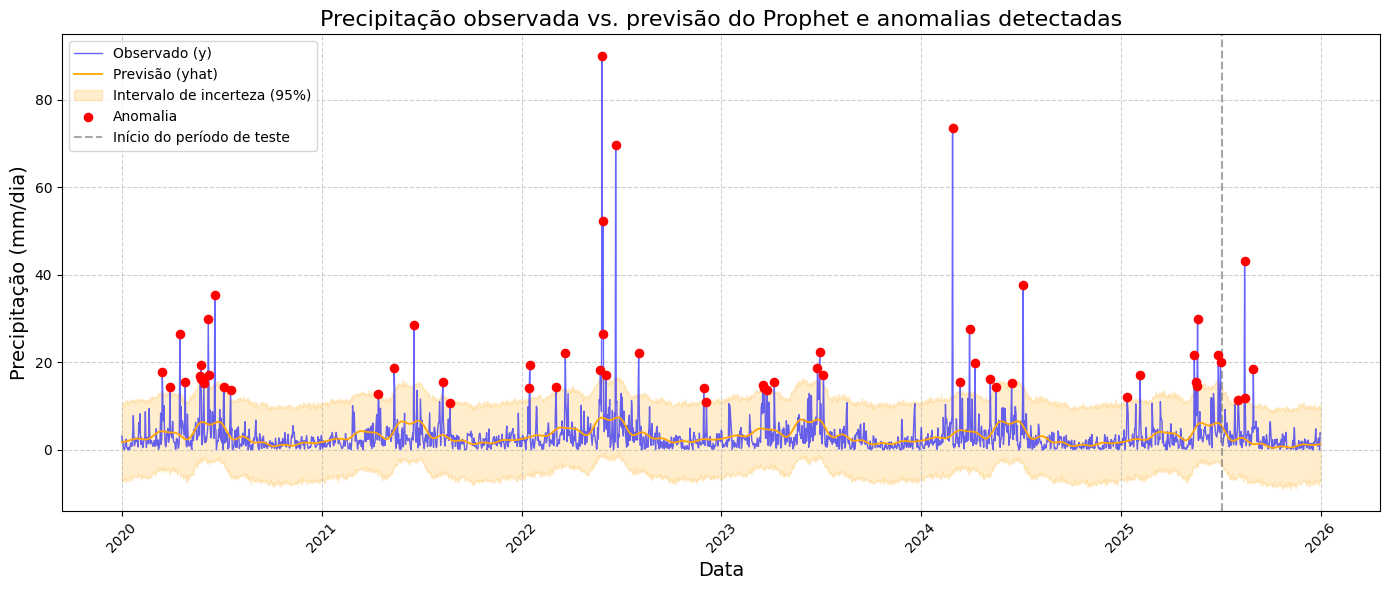

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(flagged['ds'], flagged['y'], color='b', linewidth=1, alpha=0.6, label='Observado (y)')
ax.plot(flagged['ds'], flagged['yhat'], color='orange', linewidth=1.3, label='Previsão (yhat)')
ax.fill_between(
    flagged['ds'], flagged['yhat_lower'], flagged['yhat_upper'],
    color='orange', alpha=0.2, label='Intervalo de incerteza (95%)',
)

pontos_anomalos = flagged[flagged['is_anomaly']]
ax.scatter(pontos_anomalos['ds'], pontos_anomalos['y'], color='red', s=35, zorder=5, label='Anomalia')

ax.axvline(train['ds'].max(), color='gray', linestyle='--', alpha=0.7, label='Início do período de teste')

ax.set_title('Precipitação observada vs. previsão do Prophet e anomalias detectadas', fontsize=16)
ax.set_xlabel('Data', fontsize=14)
ax.set_ylabel('Precipitação (mm/dia)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.2 - Zoom: evento extremo de maio/2022

A análise exploratória do notebook 01 documentou o valor máximo da série (89,96 mm/dia) em 28/05/2022, associado ao evento de chuvas extremas na RMR amplamente registrado pela APAC (ver `docs/apac_metodologia.md`). Aproximamos a visualização para essa janela e verificamos se o modelo identificou o(s) dia(s) como anomalia.

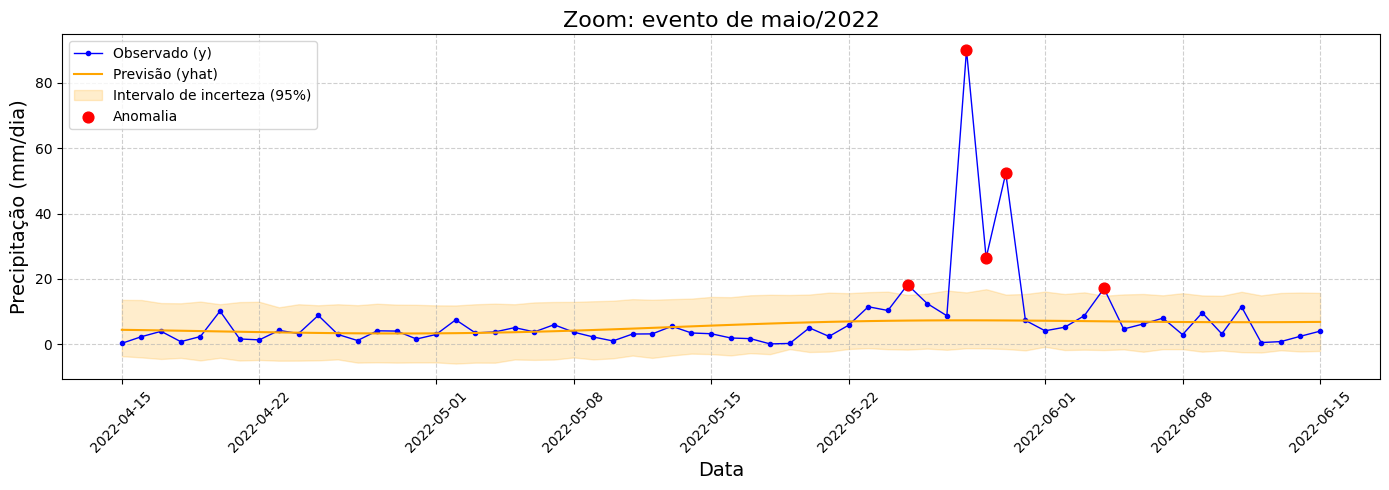

,ds,y,yhat,yhat_lower,yhat_upper,severity
875,2022-05-25,18.237219,7.283163,-1.593441,15.120815,3.116404
878,2022-05-28,89.964200,7.359259,-1.176120,15.891074,74.073126
879,2022-05-29,26.446712,7.348097,-1.205116,16.869677,9.577035
880,2022-05-30,52.305065,7.321911,-1.407613,15.220732,37.084333
885,2022-06-04,17.089764,7.056359,-1.728604,14.865461,2.224303


In [12]:
zoom = flagged[(flagged['ds'] >= '2022-04-15') & (flagged['ds'] <= '2022-06-15')]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom['ds'], zoom['y'], color='b', marker='o', markersize=3, linewidth=1, label='Observado (y)')
ax.plot(zoom['ds'], zoom['yhat'], color='orange', linewidth=1.5, label='Previsão (yhat)')
ax.fill_between(
    zoom['ds'], zoom['yhat_lower'], zoom['yhat_upper'],
    color='orange', alpha=0.2, label='Intervalo de incerteza (95%)',
)

zoom_anomalias = zoom[zoom['is_anomaly']]
ax.scatter(zoom_anomalias['ds'], zoom_anomalias['y'], color='red', s=60, zorder=5, label='Anomalia')

ax.set_title('Zoom: evento de maio/2022', fontsize=16)
ax.set_xlabel('Data', fontsize=14)
ax.set_ylabel('Precipitação (mm/dia)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zoom_anomalias[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper', 'severity']]

# 5. Interpretação Preliminar dos Resultados

**Volume de anomalias detectadas.** O modelo Prophet, ajustado com sazonalidade anual e sem sazonalidade semanal, sinalizou **58 anomalias em 2.192 dias** (2,65% da série), todas por excesso de precipitação em relação ao limite superior do intervalo de 95% (não houve anomalias por déficit — esperado, já que a série de precipitação é limitada em zero e o regime de seca não produz valores "anormalmente baixos" do ponto de vista físico). As anomalias se distribuem ao longo de praticamente todos os anos da série (2020 a 2025), concentradas nos meses tipicamente mais chuvosos da RMR (março a agosto), o que é coerente com o padrão sazonal descrito no notebook 01.

**O evento de maio/2022 foi capturado.** O dia de maior precipitação da série inteira, **28/05/2022 (89,96 mm)**, aparece marcado como anomalia — na verdade, com a maior severidade de todo o conjunto de dados (`severity` ≈ 74,1 mm acima do limite superior previsto de ~15,9 mm). Os dias vizinhos também aparecem flagados: 25/05, 29/05 e 30/05/2022, formando um cluster de anomalias consecutivas compatível com o evento de chuvas extremas de maio/2022 na RMR documentado em `docs/apac_metodologia.md`. Um segundo pico de igual natureza no mesmo ano, em 22/06/2022 (69,55 mm, severidade ≈ 52,9 mm), também foi sinalizado, sugerindo que o inverno de 2022 concentrou múltiplos eventos extremos na região.

**Outros eventos notáveis.** Fora do episódio de maio/2022, destacam-se outras anomalias de severidade elevada, como 28/02/2024 (73,55 mm, severidade ≈ 61,6 mm) e 19/06/2020 (35,45 mm, severidade ≈ 20,8 mm), que não foram objeto de documentação específica neste trabalho, mas são candidatos naturais para validação cruzada com registros da APAC na Feature 4.

**Desempenho no período de teste.** Dentro dos últimos 180 dias reservados como teste (05/07/2025 a 31/12/2025), o modelo sinalizou 4 anomalias (03/08, 15/08, 16/08 e 31/08/2025), incluindo um pico de 43,25 mm em 15/08/2025 — um indício preliminar de que o intervalo de incerteza aprendido no treino generaliza razoavelmente para dias fora da amostra, sem produzir uma taxa de alarmes falsos exageradamente alta.

**Leitura qualitativa.** No geral, o resultado é consistente com a expectativa: o modelo aprendeu um padrão sazonal suave (chuva concentrada no 2º/3º trimestre do ano) e sinaliza como anomalia justamente os picos de precipitação muito acima desse padrão esperado — entre eles, o evento historicamente mais extremo da série. Isso é uma evidência preliminar favorável ao uso do Prophet como linha de base para detecção de anomalias hidrometeorológicas na RMR, a ser aprofundada na Feature 4 com a validação formal contra o registro histórico da APAC.

**Nota sobre reprodutibilidade.** O ajuste do Prophet via otimização MAP (`cmdstanpy`) não é perfeitamente determinístico entre execuções (não há `seed` fixado em `fit_prophet_model`): reexecuções deste notebook podem produzir contagens de anomalias ligeiramente diferentes (observado entre 54 e 58 anomalias em execuções distintas), concentradas nos dias limítrofes do intervalo de incerteza. Os eventos de severidade mais alta (28/05/2022, 22/06/2022, 28/02/2024, 19/06/2020) permanecem estáveis como anomalias em todas as execuções observadas. Por isso, a partir da Seção 6, `flagged` é persistido em disco: o notebook `03_validation.ipynb` carrega esse artefato diretamente, garantindo que suas métricas sejam calculadas sobre exatamente os mesmos 58 dias aqui reportados, em vez de depender de um novo ajuste estocástico do Prophet.

## 6. Persistência de `flagged` para o Notebook 03

O ajuste do Prophet (otimização MAP via `cmdstanpy`) usa amostragem estocástica para o intervalo de incerteza e não tem `seed` fixado em `fit_prophet_model` — reexecuções deste notebook podem produzir contagens de anomalias ligeiramente diferentes a cada rodada. Para que o notebook `03_validation.ipynb` calcule suas métricas (precision, recall, F1, FPR, benchmark com a APAC) sobre o **mesmo** conjunto de anomalias aqui detectado, em vez de reajustar o Prophet de forma independente (e potencialmente divergente), persistimos `flagged` em `dados/processed/`. Isso segue a arquitetura de artefatos intermediários do projeto: cada estágio grava seu resultado em disco para permitir reexecução parcial e reprodutibilidade entre notebooks.

In [13]:
flagged_path = PROJECT_ROOT / "dados" / "processed" / "flagged_prophet_rmr_2020_2025.csv"
flagged.to_csv(flagged_path, index=False)

print(f"Salvo em: {flagged_path}")
print(f"Formato: {flagged.shape}")
flagged.head(3)

Salvo em: /mnt/c/Users/lucca/development/projects/tcc/tcc_mba/hydrometeorological-anomalies-prophet/.claude/worktrees/conclusao-tcc-prophet/dados/processed/flagged_prophet_rmr_2020_2025.csv
Formato: (2192, 7)


,ds,y,yhat,yhat_lower,yhat_upper,is_anomaly,severity
0,2020-01-01,3.148975,1.764441,-6.368066,9.847391,False,0.0
1,2020-01-02,1.878431,1.786795,-7.312250,10.163174,False,0.0
2,2020-01-03,1.916259,1.809429,-7.237746,10.608136,False,0.0
